# Segmentación de color
En este ejemplo vemos como utilizar la segmentación de color con k-means

In [84]:
from matplotlib.image import imread
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from skimage import io


In [85]:
image = imread("pexels-pixabay-36762.jpg")

In [86]:
image.shape #alto, ancho, número de canales de color

(4108, 6165, 3)

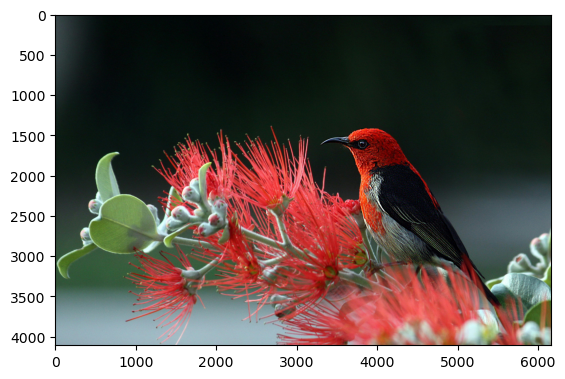

In [87]:
plt.imshow(image)

Ahora preparamos los datos para k-means que espera una estructura de la forma (n_muestras,n_caracteristicas). Cada pixel es una muestra y cada canal de color es una característica.

In [88]:
x = image.reshape(-1,3)  


In [89]:
x.shape

(25325820, 3)

Ahora aplicamos k-means para segmentar en colores

In [90]:
kmeans = KMeans(n_clusters=15)
kmeans.fit(x) #ponemos n según el número de colores que queramos

KMeans(n_clusters=15)

Aquí reconstruimos la imagen que segmentamos utilizando los centroides de cada cluster. En este caso la nueva imagen solo tendrá 30 colores diferentes.

In [91]:
segmented_image = kmeans.cluster_centers_[kmeans.labels_]


In [92]:
kmeans.cluster_centers_  #cada fila es un centroide con 3 dimensiones(RGB)


array([[122.46739903,  71.05032585,  54.97056985],
       [  9.54751015,  19.73637472,  14.99500033],
       [157.53663885, 181.02069381, 184.39457705],
       [214.7195943 ,  69.5719118 ,  66.15573749],
       [ 28.76593914,  36.26365342,  32.73056492],
       [ 82.89038664, 100.4087903 ,  97.38747457],
       [ 59.40101631,  78.46243072,  61.06610778],
       [176.47495319,  43.79035616,  38.82697436],
       [126.25122657, 146.55821397, 138.64471098],
       [169.68916078,  89.49911548,  82.22492503],
       [107.70232471,  21.1181528 ,  15.89436942],
       [108.91176871, 132.08971135,  79.86770463],
       [199.10261717, 144.54449716, 140.93810711],
       [227.8687294 ,  99.20045729,  98.64799931],
       [209.85254053, 227.50946589, 221.54984152]])

In [93]:
kmeans.labels_   #cada elemento indica el número de cluster asignado al pixel correspondiente

array([6, 6, 6, ..., 8, 8, 8], dtype=int32)

Ahora reconstruimos la imagen segmentada con el mismo tamaño y estructura que teníamos en la original

In [94]:
segmented_image = segmented_image.reshape(image.shape)

Ahora quiero mostrar la imagen con matplotlib y solo puede mostrar imágenes con valores: [0,255] si son enteros o [0,1] si son float. Aquí los normalizo para que se vea mejor. 

dtype('float64')

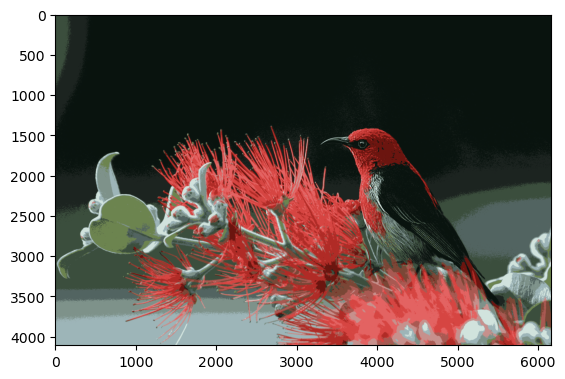

In [95]:
imagen=segmented_image/255 #para que esté entre 0 y 1
plt.imshow(imagen) 
imagen.dtype

Ahora quiero guardar la imagen, para usar io.imsave (también cv2.imwrite) necesitan imágenes en formato uint8 para poder interpretar bien los colores. Así que ahora vuelvo a recuperar los valores originales para poderla guardar correctamente

In [96]:
imagenfinal = (imagen * 255).astype(np.uint8)
io.imsave('imagen_guardada.jpg', imagenfinal)

<h1>1. Cuantización de Color con K-means<h1>

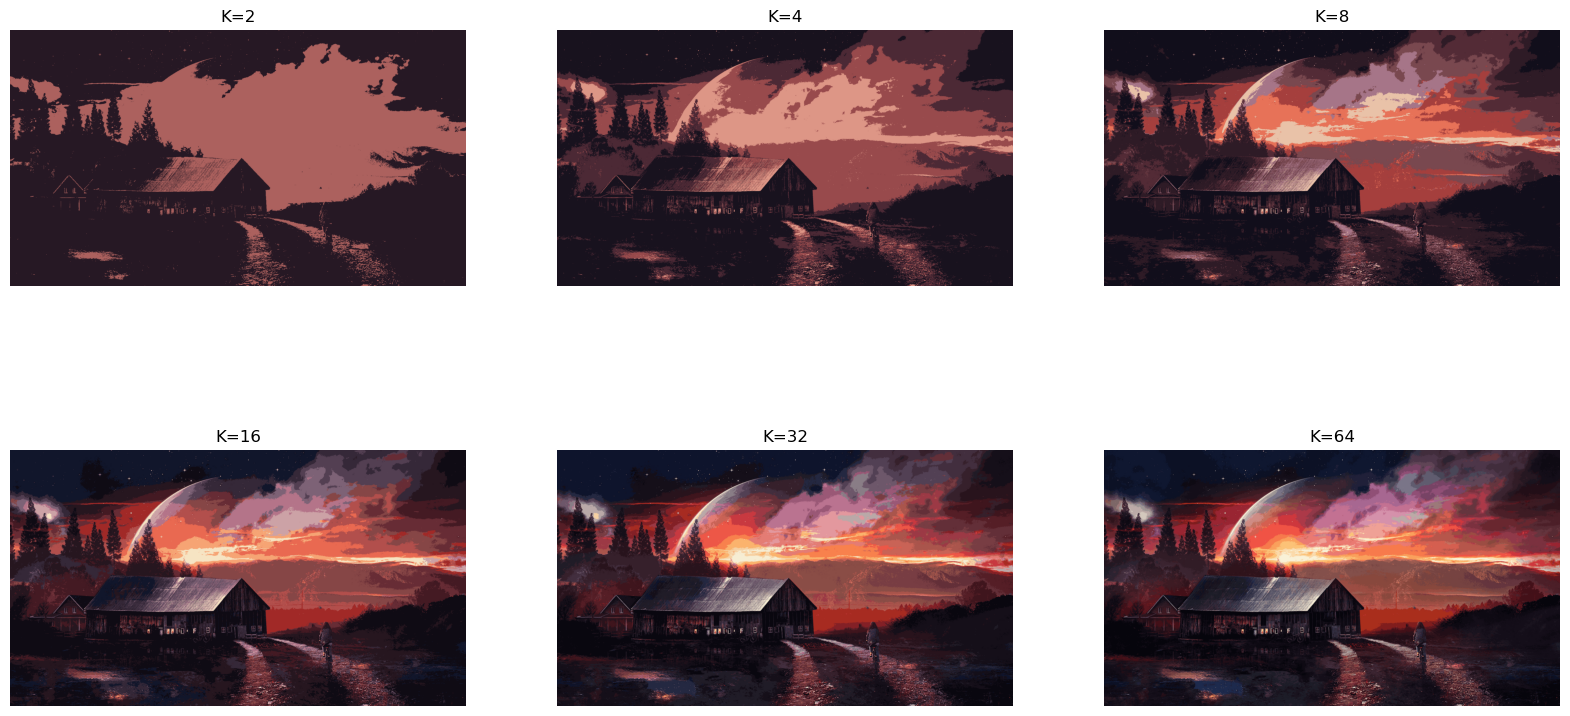

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def color_quantization(image, k=16):
    # Convertir imagen a float32 y reshape
    pixels = image.reshape((-1, 3))
    pixels = np.float32(pixels)
    
    # Definir criterios y aplicar k-means
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Convertir centros a uint8 y reconstruir imagen
    centers = np.uint8(centers)
    quantized = centers[labels.flatten()]
    quantized = quantized.reshape(image.shape)
    
    return quantized

# Cargar imagen
image = cv2.imread('Fantastic_world_Houses_456364_1920x1080.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Aplicar cuantización para diferentes valores de k
plt.figure(figsize=(20, 10))
for i, k in enumerate([2, 4, 8, 16, 32, 64], 1):
    quantized = color_quantization(image, k)
    plt.subplot(2, 3, i)
    plt.title(f'K={k}')
    plt.imshow(quantized)
    plt.axis('off')
plt.show()

<h1>2. Compresión de Imágenes<h1>

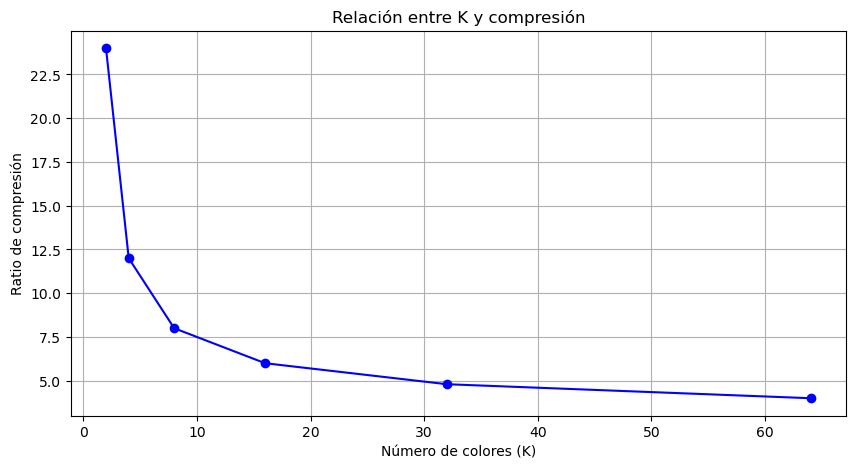

In [2]:
def calculate_compression_ratio(original, k):
    # Tamaño original (24 bits por pixel)
    original_size = original.shape[0] * original.shape[1] * 24
    
    # Tamaño comprimido (k colores + índices)
    # k colores * 24 bits + pixels * log2(k) bits
    compressed_size = k * 24 + original.shape[0] * original.shape[1] * np.ceil(np.log2(k))
    
    return original_size / compressed_size

# Probar diferentes valores de k
k_values = [2, 4, 8, 16, 32, 64]
ratios = [calculate_compression_ratio(image, k) for k in k_values]

plt.figure(figsize=(10, 5))
plt.plot(k_values, ratios, 'bo-')
plt.xlabel('Número de colores (K)')
plt.ylabel('Ratio de compresión')
plt.title('Relación entre K y compresión')
plt.grid()
plt.show()

<h1>3. Superponer un Logo en una Imagen/Video<h1>

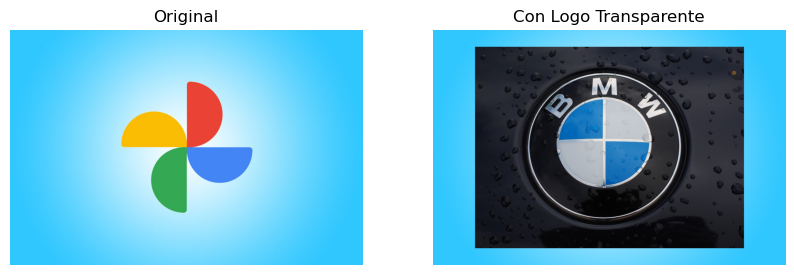

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def overlay_logo(background, logo, position=(0, 0)):
    # Hacer copias para no modificar las originales
    bg = background.copy()
    lg = logo.copy()
    
    # Convertir a RGBA si no lo están
    if bg.shape[2] == 3:
        bg = cv2.cvtColor(bg, cv2.COLOR_BGR2BGRA)
    if lg.shape[2] == 3:
        lg = cv2.cvtColor(lg, cv2.COLOR_BGR2BGRA)
    
    # Posición del logo
    x, y = position
    h, w = lg.shape[:2]
    h_bg, w_bg = bg.shape[:2]
    
    # Ajustar si el logo se sale del fondo
    if y + h > h_bg:
        h = h_bg - y
    if x + w > w_bg:
        w = w_bg - x
    
    if h <= 0 or w <= 0:
        print("Error: El logo está completamente fuera de los límites del fondo")
        return background
    
    # Recortar logo si es necesario
    lg = lg[:h, :w]
    
    # Región de interés
    roi = bg[y:y+h, x:x+w]
    
    # Máscara del logo (usando el canal alpha)
    if lg.shape[2] == 4:
        # Normalizar la máscara a [0,1]
        mask = lg[:, :, 3] / 255.0
        mask_inv = 1.0 - mask
        
        # Eliminar el área del fondo donde irá el logo
        for c in range(0, 3):
            roi[:, :, c] = (roi[:, :, c] * mask_inv).astype(np.uint8)
        
        # Añadir el logo
        for c in range(0, 3):
            roi[:, :, c] = (roi[:, :, c] + (lg[:, :, c] * mask)).astype(np.uint8)
        
        # Actualizar el canal alpha del fondo si es necesario
        if roi.shape[2] == 4:
            roi[:, :, 3] = np.maximum(roi[:, :, 3], (lg[:, :, 3] * mask).astype(np.uint8))
    
    # Actualizar la región en la imagen de fondo
    bg[y:y+h, x:x+w] = roi
    
    return cv2.cvtColor(bg, cv2.COLOR_BGRA2BGR)

# Cargar tus imágenes
background = cv2.imread('840_560.jpg')
logo = cv2.imread('bmw-4753868_1280.jpg', cv2.IMREAD_UNCHANGED)

# Verificar que las imágenes se cargaron correctamente
if background is None:
    print("Error: No se pudo cargar la imagen de fondo")
elif logo is None:
    print("Error: No se pudo cargar la imagen del logo")
else:
    # Obtener dimensiones del fondo y del logo
    h_bg, w_bg = background.shape[:2]
    h_logo, w_logo = logo.shape[:2]

    # Redimensionar el logo si es más grande que el fondo
    scale_factor = min(w_bg / w_logo, h_bg / h_logo, 0.5)  # Reducir a la mitad del tamaño máximo posible
    new_w = int(w_logo * scale_factor)
    new_h = int(h_logo * scale_factor)
    logo_resized = cv2.resize(logo, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Calcular la posición centrada
    center_x = (w_bg - new_w) // 2
    center_y = (h_bg - new_h) // 2

    # Superponer logo en el centro
    result = overlay_logo(background.copy(), logo_resized, (center_x, center_y))

    if result is not None:
        # Convertir a RGB para matplotlib
        background_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)
        result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        
        # Mostrar resultados
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title('Original')
        plt.imshow(background_rgb)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Con Logo Transparente')
        plt.imshow(result_rgb)
        plt.axis('off')
        plt.show()
        
        # Guardar el resultado
        cv2.imwrite('resultado_final.jpg', cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
    else:
        print("No se pudo superponer el logo")

<h1>4. Aplicación a Video<h1>

In [21]:
import cv2
import numpy as np

def color_quantization(image, k):
    """Reduce the number of colors in an image using k-means clustering."""
    # Reshape the image to a 2D array of pixels
    pixel_values = image.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    
    # Define criteria and apply k-means
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(
        pixel_values, 
        k, 
        None, 
        criteria, 
        10, 
        cv2.KMEANS_RANDOM_CENTERS
    )
    
    # Convert back to 8-bit values
    centers = np.uint8(centers)
    quantized_image = centers[labels.flatten()]
    quantized_image = quantized_image.reshape(image.shape)
    
    return quantized_image

def overlay_logo(image, logo, position):
    """Overlay a logo on the image at the specified position."""
    x, y = position
    h, w = logo.shape[:2]
    
    # Ensure the logo fits within the image
    if x + w > image.shape[1] or y + h > image.shape[0]:
        raise ValueError("Logo position is outside the image bounds.")
    
    # If logo has an alpha channel (transparency), blend it
    if logo.shape[2] == 4:
        alpha = logo[:, :, 3] / 255.0
        for c in range(3):
            image[y:y+h, x:x+w, c] = (
                alpha * logo[:, :, c] + 
                (1 - alpha) * image[y:y+h, x:x+w, c]
            )
    else:
        image[y:y+h, x:x+w] = logo
    
    return image

def process_video(input_path, output_path, logo=None, k=None):
    cap = cv2.VideoCapture(input_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Apply color quantization if specified
        if k is not None:
            frame = color_quantization(frame, k)
        
        # Overlay logo if provided
        if logo is not None:
            frame = overlay_logo(frame, logo, (50, 50))
        
        # Write processed frame
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    
    cap.release()
    out.release()

# Example usage
logo = cv2.imread('bmw-4753868_1280.jpg', cv2.IMREAD_UNCHANGED)  # Ensure the logo has transparency (PNG)
process_video('input.mp4', 'output.mp4', logo=logo, k=16)  # Reduce to 16 colors

<h1>5. Creación de Máscaras<h1>

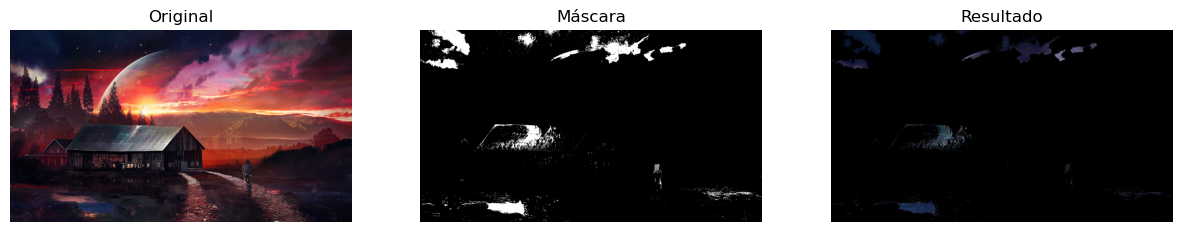

In [6]:
def create_color_mask(image, lower, upper):
    # Convertir a HSV (mejor para detección de color)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    
    # Crear máscara
    mask = cv2.inRange(hsv, lower, upper)
    
    # Aplicar máscara
    result = cv2.bitwise_and(image, image, mask=mask)
    
    return mask, result

# Ejemplo: extraer tonos azules
image = cv2.imread('Fantastic_world_Houses_456364_1920x1080.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Rango de colores azules en HSV
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

mask, result = create_color_mask(image, lower_blue, upper_blue)

# Mostrar resultados
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title('Original')
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Máscara')
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Resultado')
plt.imshow(result)
plt.axis('off')
plt.show()